In [6]:
!pip install mlxtend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_auc_score, roc_curve,
                             mean_squared_error, r2_score, silhouette_score, davies_bouldin_score)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_csv('Air_Quality_Measures_on_the_National_Environmental_Health_Tracking_Network (1).csv')
df 

,MeasureId,MeasureName,MeasureType,StratificationLevel,StateFips,StateName,CountyFips,CountyName,ReportYear,Value,Unit,UnitName,DataOrigin,MonitorOnly
0,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1027,Clay,1999,33.000000,No Units,No Units,Monitor Only,1
1,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1051,Elmore,1999,5.000000,No Units,No Units,Monitor Only,1
2,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1073,Jefferson,1999,39.000000,No Units,No Units,Monitor Only,1
3,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1079,Lawrence,1999,28.000000,No Units,No Units,Monitor Only,1
4,83,Number of days with maximum 8-hour average ozo...,Counts,State x County,1,Alabama,1089,Madison,1999,31.000000,No Units,No Units,Monitor Only,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218630,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2007,6.207126,µg/m³,Micograms per cubic meter,Monitor & Modeled,0
218631,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2008,6.369764,µg/m³,Micograms per cubic meter,Monitor & Modeled,0
218632,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2009,6.241708,µg/m³,Micograms per cubic meter,Monitor & Modeled,0
218633,296,Annual average ambient concentrations of PM 2....,Average,State x County,56,Wyoming,56045,Weston,2010,6.125957,µg/m³,Micograms per cubic meter,Monitor & Modeled,0


In [5]:
print(df.isnull().sum())

MeasureId              0
MeasureName            0
MeasureType            0
StratificationLevel    0
StateFips              0
StateName              0
CountyFips             0
CountyName             0
ReportYear             0
Value                  0
Unit                   0
UnitName               0
DataOrigin             0
MonitorOnly            0
dtype: int64


In [7]:
if 'Value' in df.columns:
    scaler = MinMaxScaler()
    df['Value_scaled'] = scaler.fit_transform(df[['Value']])

In [8]:
categorical_columns = ['StateName', 'CountyName']  # Adjust based on your dataset
for col in categorical_columns:
    if col in df.columns:
        df = pd.get_dummies(df, columns=[col], drop_first=True)

In [ ]:
df = df[df['ReportYear'] > 2000]

In [10]:
df = df[df['StateName_California'] == 1]

In [11]:
treated = df[df['MonitorOnly'] == 1]
control = df[df['MonitorOnly'] == 0]

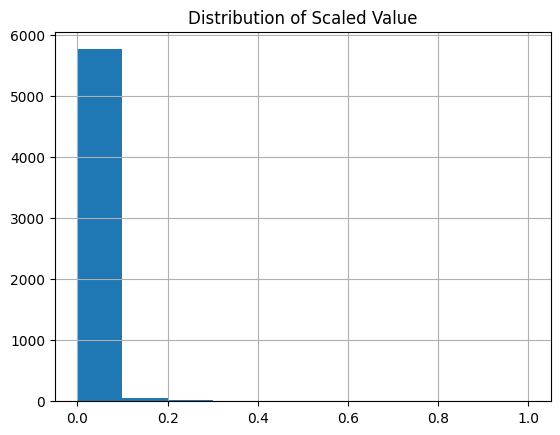

In [12]:
df['Value_scaled'].hist()
plt.title('Distribution of Scaled Value')
plt.show()

In [113]:
df = pd.read_csv('separated_measures\pm25_concentration_monitor.csv')
df


,MeasureId,MeasureType,StratificationLevel,StateFips,StateName,CountyFips,CountyName,ReportYear,Value,Unit,UnitName,DataOrigin,MonitorOnly,MeasureKey
0,87,Average,State x County,54,West Virginia,54081,Raleigh,2003,12.349080,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
1,87,Average,State x County,12,Florida,12033,Escambia,2002,10.953455,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
2,87,Average,State x County,29,Missouri,29099,Jefferson,1999,15.155819,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
3,87,Average,State x County,30,Montana,30029,Flathead,2001,8.272648,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
4,87,Average,State x County,12,Florida,12103,Pinellas,2006,9.553561,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8417,87,Average,State x County,35,New Mexico,35049,Santa Fe,2000,5.217125,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
8418,87,Average,State x County,40,Oklahoma,40135,Sequoyah,2005,14.118101,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
8419,87,Average,State x County,33,New Hampshire,33011,Hillsborough,2001,10.826305,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor
8420,87,Average,State x County,49,Utah,49035,Salt Lake,2010,10.954182,µg/m³,Micograms per cubic meter,Monitor Only,1,PM25_Concentration_Monitor


In [96]:
df = df.drop(['MeasureId','StateName', 'MeasureType', 'StratificationLevel','Unit','UnitName','CountyName','DataOrigin'	,'MonitorOnly'	,'MeasureKey'],axis=1)

In [97]:
df

,StateFips,CountyFips,ReportYear,Value
0,54,54081,2003,12.349080
1,12,12033,2002,10.953455
2,29,29099,1999,15.155819
3,30,30029,2001,8.272648
4,12,12103,2006,9.553561
...,...,...,...,...
8417,35,35049,2000,5.217125
8418,40,40135,2005,14.118101
8419,33,33011,2001,10.826305
8420,49,49035,2010,10.954182


In [38]:
def categorize_aqi(value):
    """Categorize air quality based on number of exceedance days"""
    if value <= 10:
        return 'Good'
    elif value <= 25:
        return 'Moderate'
    elif value <= 50:
        return 'Unhealthy for Sensitive'
    elif value <= 75:
        return 'Unhealthy'
    else:
        return 'Very Unhealthy'

df['AQI_Category'] = df['Value'].apply(categorize_aqi)

In [57]:
le_state = LabelEncoder()
le_county = LabelEncoder()
df['State_Encoded'] = le_state.fit_transform(df['StateName'])
# df['County_Encoded'] = le_county.fit_transform(df['CountyName'])
df = df.drop(['StateName'],axis=1)

In [98]:
scaler = MinMaxScaler()
df['Value_scaled'] = scaler.fit_transform(df[['Value']])
df = df.drop(['Value'],axis=1)

In [99]:
X = df.drop(["Value_scaled"],axis=1)
y = df['Value_scaled']

In [100]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [101]:
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

regression_results = {}

In [102]:
lr_model = LinearRegression()
lr_model.fit(X_train_reg_scaled, y_train_reg)
y_pred_lr = lr_model.predict(X_test_reg_scaled)

In [103]:
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = np.mean(np.abs(y_test_reg - y_pred_lr))

print(f"MSE (Mean Squared Error):     {mse_lr:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse_lr:.4f}")
print(f"R² Score:                       {r2_lr:.4f}")
print(f"MAE (Mean Absolute Error):      {mae_lr:.4f}")

MSE (Mean Squared Error):     0.0033
RMSE (Root Mean Squared Error): 0.0571
R² Score:                       0.2074
MAE (Mean Absolute Error):      0.0436


In [89]:
features = ["StateFips","CountyFips",	"ReportYear",	"Value","State_Encoded"]
for feat, coef in zip(features, lr_model.coef_):
    print(f"   {feat}: {coef:.4f}")
print(f"   Intercept: {lr_model.intercept_:.4f}")

   StateFips: -0.1840
   CountyFips: 0.1798
   ReportYear: -0.0497
   Intercept: 0.0555


In [107]:
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_model = Ridge()
ridge_grid = GridSearchCV(ridge_model, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_reg_scaled, y_train_reg)

ridge_best = ridge_grid.best_estimator_
y_pred_ridge = ridge_best.predict(X_test_reg_scaled)


In [105]:
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
mae_ridge = np.mean(np.abs(y_test_reg - y_pred_ridge))

In [108]:
print(f"MSE:  {mse_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R² Score: {r2_ridge:.4f}")
print(f"MAE:  {mae_ridge:.4f}")

MSE:  0.0033
RMSE: 0.0571
R² Score: 0.2074
MAE:  0.0436


In [109]:
rf_reg_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_reg_model = RandomForestRegressor(random_state=42)
rf_reg_grid = GridSearchCV(rf_reg_model, rf_reg_params, cv=3, scoring='r2', n_jobs=-1)
rf_reg_grid.fit(X_train_reg, y_train_reg)

print(f"   Best Parameters: {rf_reg_grid.best_params_}")
print(f"   Best CV Score: {rf_reg_grid.best_score_:.4f}")

rf_reg_best = rf_reg_grid.best_estimator_
y_pred_rf_reg = rf_reg_best.predict(X_test_reg)



   Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
   Best CV Score: 0.6743


In [110]:

mse_rf_reg = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)
mae_rf_reg = np.mean(np.abs(y_test_reg - y_pred_rf_reg))

print(f"MSE:  {mse_rf_reg:.4f}")
print(f"RMSE: {rmse_rf_reg:.4f}")
print(f"R² Score: {r2_rf_reg:.4f}")
print(f"MAE:  {mae_rf_reg:.4f}")

MSE:  0.0010
RMSE: 0.0320
R² Score: 0.7511
MAE:  0.0218


In [ ]:
from statsmodels.formula.api import ols

model = ols('Value_scaled ~ MonitorOnly + ReportYear', data=df).fit()
print(model.summary())

PatsyError: model is missing required outcome variables

In [115]:
def categorize_pm25(x):
    if x == 0:
        return "PM25_None"
    elif x <= 5:
        return "PM25_Low"
    else:
        return "PM25_High"

df["PM25_Category"] = df["Value"].apply(categorize_pm25)

# Convert CountyFips into categorical item
df["County"] = "County_" + df["CountyFips"].astype(str)

# Convert Year into item
df["Year"] = "Year_" + df["ReportYear"].astype(str)

# Select only the columns needed for FPM
df_fpm = df[["County", "Year", "PM25_Category"]]

print("Selected Fields for FPM:")
df_fpm.head()

Selected Fields for FPM:


,County,Year,PM25_Category
0,County_54081,Year_2003,PM25_High
1,County_12033,Year_2002,PM25_High
2,County_29099,Year_1999,PM25_High
3,County_30029,Year_2001,PM25_High
4,County_12103,Year_2006,PM25_High


In [116]:
transactions = df_fpm.values.tolist()

print("Sample Transactions:")
for t in transactions[:5]:
    print(t)

Sample Transactions:
['County_54081', 'Year_2003', 'PM25_High']
['County_12033', 'Year_2002', 'PM25_High']
['County_29099', 'Year_1999', 'PM25_High']
['County_30029', 'Year_2001', 'PM25_High']
['County_12103', 'Year_2006', 'PM25_High']


In [117]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("One-Hot Encoded Data:")
df_encoded.head()

One-Hot Encoded Data:


,County_10001,County_10003,County_10005,County_1003,County_1027,County_1033,County_1049,County_1053,County_1055,County_1069,...,Year_2004,Year_2005,Year_2006,Year_2007,Year_2008,Year_2009,Year_2010,Year_2011,Year_2012,Year_2013
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [118]:
frequent_itemsets_ap = apriori(df_encoded, min_support=0.1, use_colnames=True)

print("Frequent Itemsets (Apriori):")
frequent_itemsets_ap.head()

# Generate association rules
rules_ap = association_rules(frequent_itemsets_ap, metric="confidence", min_threshold=0.6)

print("Apriori Rules:")
rules_ap.sort_values(by="lift", ascending=False).head()

Frequent Itemsets (Apriori):
Apriori Rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
